d:\anaconda3\envs\my_quan\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


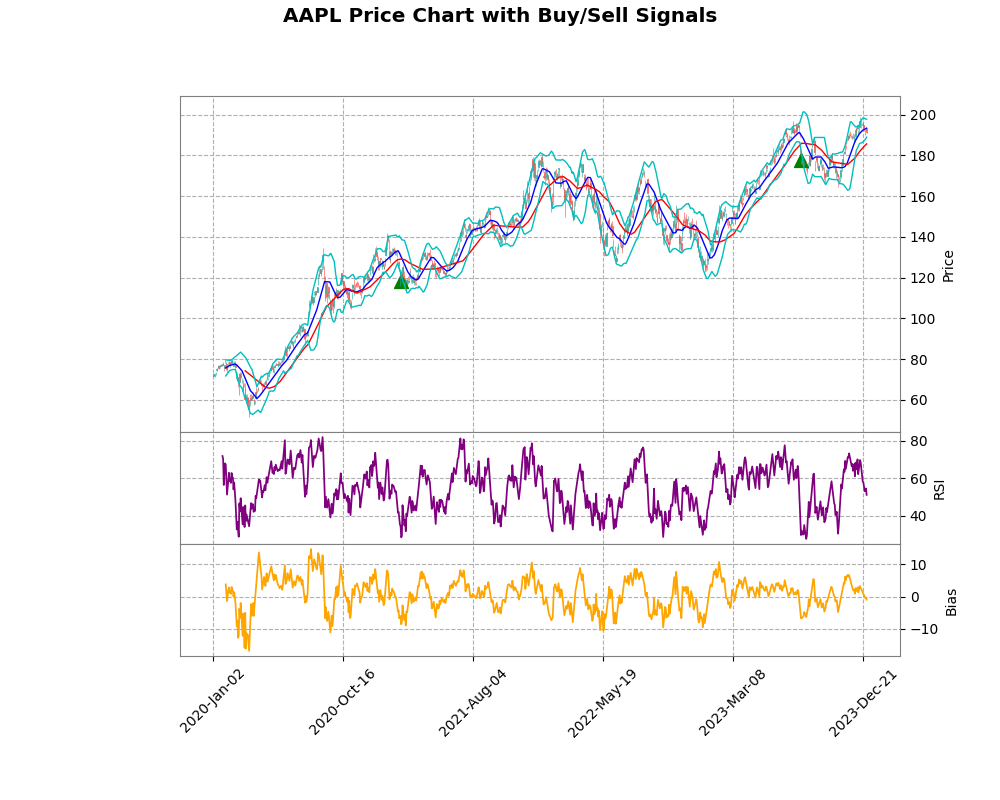

In [10]:
%matplotlib widget
import yfinance as yf
import talib as ta
import mplfinance as mpf
import numpy as np

# 获取数据
ticker = 'AAPL'
tk = yf.Ticker('AAPL')
data = tk.history(start='2020-01-01', end='2024-01-01')

# 计算技术指标
data['SMA_20'] = ta.SMA(data['Close'], timeperiod=20)
data['SMA_50'] = ta.SMA(data['Close'], timeperiod=50)
data['upper_band'], data['middle_band'], data['lower_band'] = ta.BBANDS(data['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
data['RSI'] = ta.RSI(data['Close'], timeperiod=14)
data['Bias'] = (data['Close'] / data['SMA_20'] - 1) * 100

# 策略信号：买入信号和卖出信号
data['buy_signal'] = (
    (data['SMA_20'] > data['SMA_50']) &  # 短期均线 > 长期均线
    (data['Close'] < data['lower_band']) &  # 股价跌破布林带下轨
    (data['RSI'] < 30) &  # RSI < 30 (超卖)
    (data['Bias'] < -5)  # Bias < -5
)

data['sell_signal'] = (
    (data['SMA_20'] < data['SMA_50']) &  # 短期均线 < 长期均线
    (data['Close'] > data['upper_band']) &  # 股价突破布林带上轨
    (data['RSI'] > 70) &  # RSI > 70 (超买)
    (data['Bias'] > 5)  # Bias > 5
)

# 准备 mplfinance 绘制数据
plot_data = data.copy()
plot_data.index.name = 'Date'

# 获取买卖信号的位置
buy_positions = data[data['buy_signal'] == True].index
sell_positions = data[data['sell_signal'] == True].index

# 将买卖信号的位置转换为整数索引
buy_positions_int = [data.index.get_loc(date) for date in buy_positions] if len(buy_positions) > 0 else []
sell_positions_int = [data.index.get_loc(date) for date in sell_positions] if len(sell_positions) > 0 else []

# 创建买卖信号的标记，确保如果信号为空，传递的数组不会导致错误
buy_signals = np.full(len(data), np.nan)  # 默认为 NaN
sell_signals = np.full(len(data), np.nan)  # 默认为 NaN

# 如果有买入信号，则填充相应位置
if len(buy_positions_int) > 0:
    buy_signals[buy_positions_int] = data['Close'][buy_positions]

# 如果有卖出信号，则填充相应位置
if len(sell_positions_int) > 0:
    sell_signals[sell_positions_int] = data['Close'][sell_positions]

# 创建买卖信号的 `addplot`
buy_signals_plot = mpf.make_addplot(buy_signals, type='scatter', markersize=100, marker='^', color='g', panel=0)
sell_signals_plot = mpf.make_addplot(sell_signals, type='scatter', markersize=100, marker='v', color='r', panel=0)

# 检查添加信号的过程，确保 buy_signals 和 sell_signals 数组不会为空
apds = [
    mpf.make_addplot(plot_data['SMA_20'], color='blue', width=1.0, panel=0),
    mpf.make_addplot(plot_data['SMA_50'], color='red', width=1.0, panel=0),
    mpf.make_addplot(plot_data['upper_band'], color='c', width=1.0, panel=0),
    mpf.make_addplot(plot_data['lower_band'], color='c', width=1.0, panel=0),
    mpf.make_addplot(plot_data['RSI'], color='purple', panel=1, ylabel='RSI'),
    mpf.make_addplot(plot_data['Bias'], color='orange', panel=2, ylabel='Bias'),
]

# 只有在信号非空时才添加信号图层
if len(buy_positions_int) > 0:
    apds.append(buy_signals_plot)

if len(sell_positions_int) > 0:
    apds.append(sell_signals_plot)

# 绘制最终图表
mpf.plot(
    plot_data,
    type='candle',
    style='tradingview',
    title=f"{ticker} Price Chart with Buy/Sell Signals",
    ylabel='Price',
    addplot=apds,
    figsize=(10, 8),
    panel_ratios=(3, 1, 1)
)
